In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [46]:
file = "Catchment water balance data.xlsx"
df = pd.read_excel(file, index_col= 0, parse_dates= True, skiprows = 2)


df.columns = ["P1","EP1","Q1","P2","EP2","Q2","P3","EP3","Q3","empty1","empty2","empty3"]

df = df.drop(columns=["empty1","empty2","empty3"])
df.head(10)
catchment_1 = df[["P1","EP1","Q1"]]
catchment_2 = df[["P2","EP2","Q2"]]
catchment_3 = df[["P3","EP3","Q3"]]

P1 = catchment_1["P1"].mean()
EP1 = catchment_1["EP1"].mean()
Q1 = catchment_1["Q1"].mean()
EA1 = P1 - Q1

P2 = catchment_2["P2"].mean()
EP2 = catchment_2["EP2"].mean()
Q2 = catchment_2["Q2"].mean()
EA2 = P2 - Q2

P3 = catchment_3["P3"].mean()
EP3 = catchment_3["EP3"].mean()
Q3 = catchment_3["Q3"].mean()
EA3 = P3 - Q3

print("Catchment 1: P =", catchP1, "EP =", EP1, "Q =", Q1)
print("Catchment 2: P =", P2, "EP =", EP2, "Q =", Q2)
print("Catchment 3: P =", P3, "EP =", EP3, "Q =", Q3)



Catchment 1: P = 2.833886375062846 EP = 1.8966063348416289 Q = 0.45040346907993967
Catchment 2: P = 1.983720462543992 EP = 2.6552488687782803 Q = 0.45040346907993967
Catchment 3: P = 1.416943187531423 EP = 3.603552036199095 Q = 0.45040346907993967


C:\Users\laura\AppData\Local\Temp\ipykernel_23540\3009203865.py:10: RuntimeWarning: divide by zero encountered in divide
  return np.sqrt(phi * np.tanh(1/phi) * (1 - np.exp(-phi)))


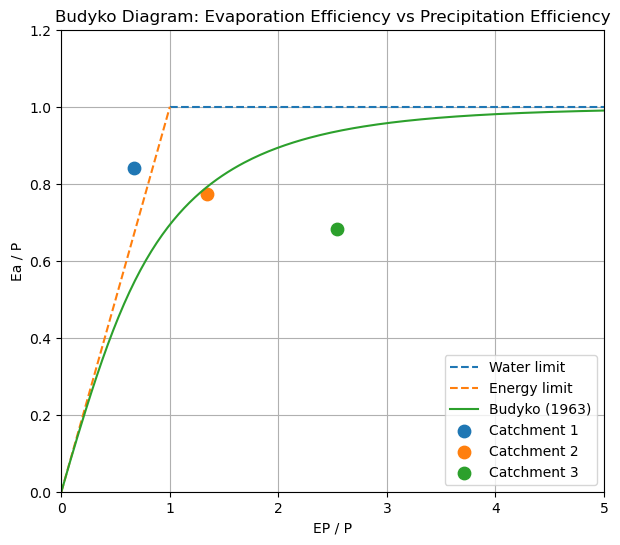

In [60]:
phi1 = EP1 / P1
phi2 = EP2 / P2
phi3 = EP3 / P3

ei1 = EA1 / P1
ei2 = EA2 / P2
ei3 = EA3 / P3

def budyko(phi):
    return np.sqrt(phi * np.tanh(1/phi) * (1 - np.exp(-phi)))

x = np.linspace(0,5,200)

budyko_curve = budyko(x)
plt.figure(figsize=(7,6))
x_water = np.linspace(1,5,100)
plt.plot(x_water, np.ones_like(x_water), "--", label="Water limit")
x_energy = np.linspace(0,1,100)
plt.plot(x_energy, x_energy, "--", label="Energy limit")


plt.plot(x, budyko_curve, label="Budyko (1963)")


plt.scatter(phi1, ei1, s=80, label="Catchment 1")
plt.scatter(phi2, ei2, s=80, label="Catchment 2")
plt.scatter(phi3, ei3, s=80, label="Catchment 3")
plt.title("Budyko Diagram: Evaporation Efficiency vs Precipitation Efficiency")

plt.xlabel("EP / P")
plt.ylabel("Ea / P")
plt.xlim(0, 5)
plt.ylim(0, 1.2)
plt.grid(True)
plt.legend()
plt.show()

  Catchment         P        EP         Q  phi = EP/P  EA_data = P-Q  \
0         1  2.833886  1.896606  0.450403    0.669260       2.383483   
1         2  1.983720  2.655249  0.450403    1.338520       1.533317   
2         3  1.416943  3.603552  0.450403    2.543187       0.966540   

   EA_budyko  Residual = P-(EA+Q)  
0   1.539775             0.843708  
1   1.568901            -0.035584  
2   1.326688            -0.360148  


C:\Users\laura\AppData\Local\Temp\ipykernel_23540\3009203865.py:10: RuntimeWarning: divide by zero encountered in divide
  return np.sqrt(phi * np.tanh(1/phi) * (1 - np.exp(-phi)))


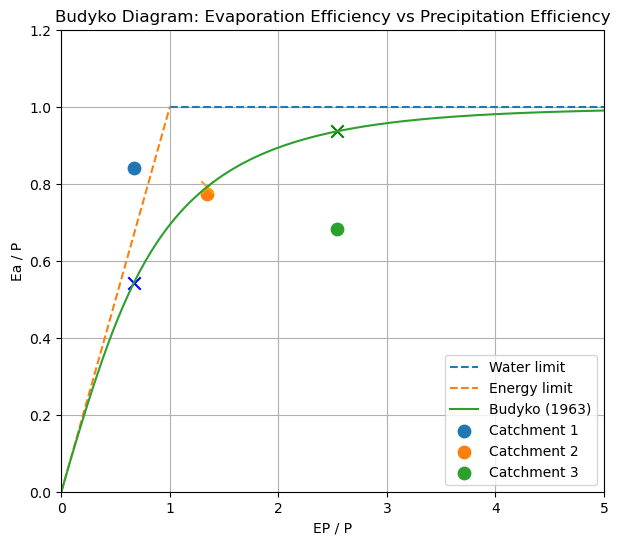

In [105]:
EA1_budyko = P1 * budyko(phi1)
EA2_budyko = P2 * budyko(phi2)
EA3_budyko = P3 * budyko(phi3)


residual1 = P1 - (EA1_budyko + Q1)
residual2 = P2 - (EA2_budyko + Q2)
residual3 = P3 - (EA3_budyko + Q3)

results = pd.DataFrame({
    "Catchment": ["1", "2", "3"],
    "P": [P1, P2, P3],
    "EP": [EP1, EP2, EP3],
    "Q": [Q1, Q2, Q3],
    "phi = EP/P": [phi1, phi2, phi3],
    "EA_data = P-Q": [
        catchment_1["EA1"].mean(),
        catchment_2["EA2"].mean(),
        catchment_3["EA3"].mean()
    ],
    "EA_budyko": [EA1_budyko, EA2_budyko, EA3_budyko],
    "Residual = P-(EA+Q)": [residual1, residual2, residual3]
})


print(results)

x = np.linspace(0,5,200)

budyko_curve = budyko(x)
plt.figure(figsize=(7,6))
x_water = np.linspace(1,5,100)
plt.plot(x_water, np.ones_like(x_water), "--", label="Water limit")
x_energy = np.linspace(0,1,100)
plt.plot(x_energy, x_energy, "--", label="Energy limit")


plt.plot(x, budyko_curve, label="Budyko (1963)")

budyko1 = budyko(phi1)
budyko2 = budyko(phi2)
budyko3 = budyko(phi3)
plt.scatter(phi1, ei1, s=80, label="Catchment 1")
plt.scatter(phi2, ei2, s=80, label="Catchment 2")
plt.scatter(phi3, ei3, s=80, label="Catchment 3")
plt.scatter(phi1, budyko1, color="blue", marker="x", s=80)
plt.scatter(phi2, budyko2, color="orange", marker="x", s=80)
plt.scatter(phi3, budyko3, color="green", marker="x", s=80)
plt.title("Budyko Diagram: Evaporation Efficiency vs Precipitation Efficiency")

plt.xlabel("EP / P")
plt.ylabel("Ea / P")
plt.xlim(0, 5)
plt.ylim(0, 1.2)
plt.grid(True)
plt.legend()
plt.show()


<Axes: >

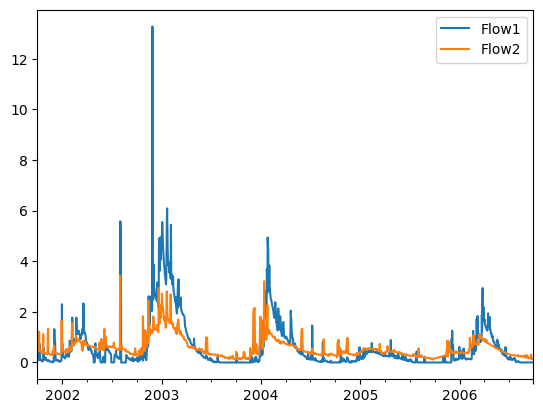

In [101]:
#exercise 2 flow duration curve


filename = "Flow duration curve data.xlsx"
df_fdc = pd.read_excel(filename, index_col=0, parse_dates=True, skiprows = 1)
df_fdc.columns = ["Flow1", "Flow2"]
df_fdc.head()

df_fdc.plot()



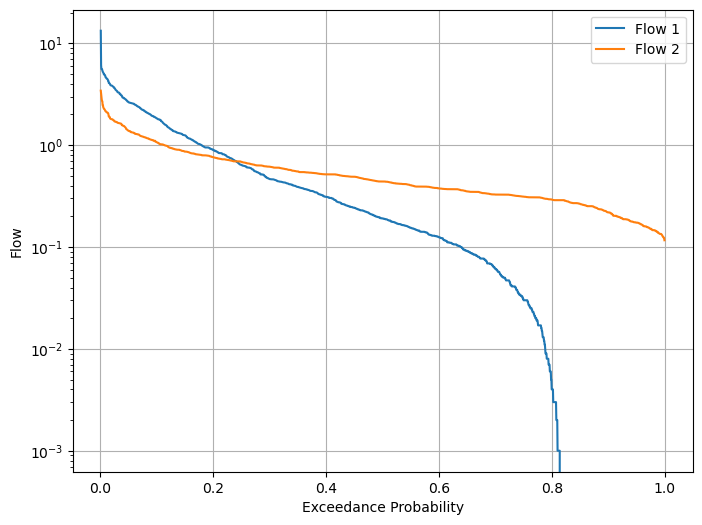

In [100]:
flow1 = df_fdc["Flow1"]
flow2 = df_fdc["Flow2"]

sorted_1 = flow1.sort_values(ascending=False)
sorted_2 = flow2.sort_values(ascending=False)

n_data = len(sorted_1)

rank = np.arange(1, n_data + 1)
exceedance_probability = rank / (n_data + 1)

plt.figure(figsize=(8,6))

plt.plot(exceedance_probability, sorted_1, label="Flow 1")
plt.plot(exceedance_probability, sorted_2, label="Flow 2")
plt.yscale("log")

plt.xlabel("Exceedance Probability")
plt.ylabel("Flow")
plt.legend()
plt.grid()

plt.show()

In [102]:
# The shape of the flow duration curve (FDC) provides information about the variability of discharge in a catchment and how quickly it responds to precipitation.

# A steeper curve indicates large differences between high flows and low flows. This means that the catchment reacts quickly to rainfall events and produces flashy peaks. Such a catchment has limited storage capacity (e.g., less groundwater buffering), so runoff increases rapidly after precipitation and also decreases quickly afterwards.

# A flatter curve indicates that the discharge varies less over time. This means the catchment has a more regular flow regime with smaller differences between high and low flows. This behaviour often occurs in catchments with larger groundwater storage or other buffering processes that regulate the flow.

# Based on the flow duration curves:

# The catchment with the steeper flow duration curve responds faster to rainfall and has flashier peaks.

# The catchment with the flatter curve has a more regular and stable flow regime.

# This can be seen from the slope of the FDC: a steep slope indicates high variability and flashy behaviour, while a gentle slope indicates more stable discharge conditions.

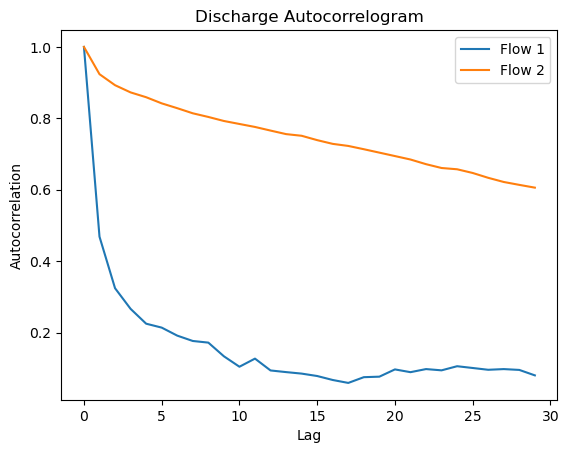

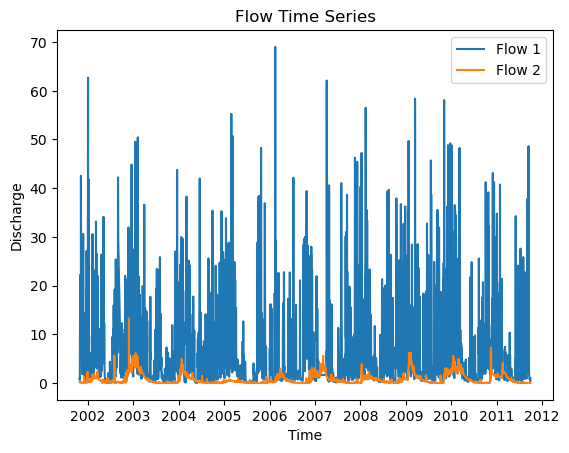

In [117]:
#exercise 3

filename = "Autocorrelation function data.xlsx"
df_acf = pd.read_excel(filename, index_col=0, parse_dates=True, skiprows = 1)
df_acf.head()
df_acf.columns = ["Flow1", "Flow2"]

lags = np.arange(30)
auto1 = []
auto2 = []
for i in range(len(lags)):
    auto1.append(df_acf["Flow1"].autocorr(lag = i))
    auto2.append(df_acf["Flow2"].autocorr(lag = i))


plt.plot(lags, auto1, label="Flow 1")
plt.plot(lags, auto2, label="Flow 2")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("Discharge Autocorrelogram")
plt.legend()
plt.show()
plt.plot(df_acf["Flow1"], label="Flow 1")
plt.plot(df_acf["Flow2"], label="Flow 2")
plt.xlabel("Time")
plt.ylabel("Discharge")
plt.title("Flow Time Series")
plt.legend()
plt.show()










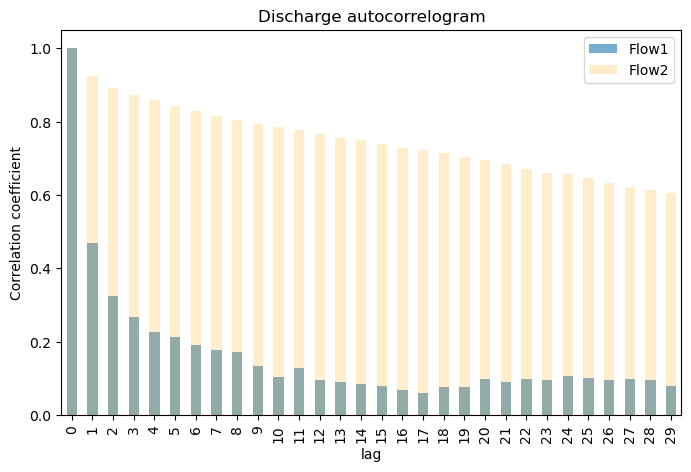

In [122]:
acf1 = pd.Series(
    [df_acf["Flow1"].autocorr(lag) for lag in lags],
    index=pd.Index(lags, name="lag")
)

acf2 = pd.Series(
    [df_acf["Flow2"].autocorr(lag) for lag in lags],
    index=pd.Index(lags, name="lag")
)

plt.figure(figsize=(8,5))

acf1.plot.bar(alpha=0.6, label="Flow1")
acf2.plot.bar(alpha=0.2, label="Flow2", color="orange")

plt.ylabel("Correlation coefficient")
plt.title("Discharge autocorrelogram")
plt.legend()